### [(Auto) ARIMA & SARIMAX Tuned Models](https://blog.gopenai.com/using-skforecast-for-multiple-ml-time-series-forecasting-tsf-across-industries-2-14a80ce7ada1)

> Comparing Skforecast, pmdarima & statsmodels SARIMAX models with backtesting, grid search & AutoARIMA tuning

Unlock the power of Skforecast SARIMAX predictions vs pmdarima & statsmodels (Auto)ARIMA with ForecasterSarimax backtesting & hyperparameter optimization (HPO) in Python.

Explore **ARIMA (AutoRegressive Integrated Moving Average)** and **SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors)** TSF.

In [1]:
from dotenv import load_dotenv, dotenv_values
load_dotenv()

True

In [2]:
!pip install -q "numpy==1.26.4" "pandas==2.2.2" statsmodels
!pip install -q matplotlib plotly pmdarima "seaborn>=0.11,<0.14"
!pip install -q skforecast skforecast[plotting]

In [3]:
import numpy as np
import pandas as pd
from io import StringIO
import contextlib
import re
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')

# pmdarima
import pmdarima
from pmdarima import ARIMA
from pmdarima import auto_arima

# statsmodels
import statsmodels
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# skforecast
import skforecast
from skforecast.datasets import fetch_dataset
from skforecast.plot import set_dark_theme
from skforecast.sarimax import Sarimax
from skforecast.recursive import ForecasterSarimax
from skforecast.model_selection import TimeSeriesFold
from skforecast.model_selection import backtesting_sarimax
from skforecast.model_selection import grid_search_sarimax

import warnings
warnings.filterwarnings('ignore')

color = '\033[1m\033[38;5;208m' 
print(f"{color}Version skforecast: {skforecast.__version__}")
print(f"{color}Version pdarima: {pmdarima.__version__}")
print(f"{color}Version statsmodels: {statsmodels.__version__}")
print(f"{color}Version pandas: {pd.__version__}")
print(f"{color}Version numpy: {np.__version__}")

Version skforecast: 0.15.1
Version pdarima: 2.0.4
Version statsmodels: 0.14.4
Version pandas: 2.2.2
Version numpy: 1.26.4


In [4]:
data = fetch_dataset(name='fuel_consumption', raw=True)
data = data[['Fecha', 'Gasolinas']]
data = data.rename(columns={'Fecha':'date', 'Gasolinas':'litters'})
data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')
data = data.set_index('date')
data = data.loc[:'1999-01-01 00:00:00']
data = data.asfreq('MS')
data = data['litters']

fuel_consumption
----------------
Monthly fuel consumption in Spain from 1969-01-01 to 2022-08-01.
Obtained from Corporación de Reservas Estratégicas de Productos Petrolíferos and
Corporación de Derecho Público tutelada por el Ministerio para la Transición
Ecológica y el Reto Demográfico. https://www.cores.es/es/estadisticas
Shape of the dataset: (644, 6)


Train dates : 1969-01-01 00:00:00 --- 1988-01-01 00:00:00  (n=229)
Test dates  : 1988-02-01 00:00:00 --- 1999-01-01 00:00:00  (n=132)


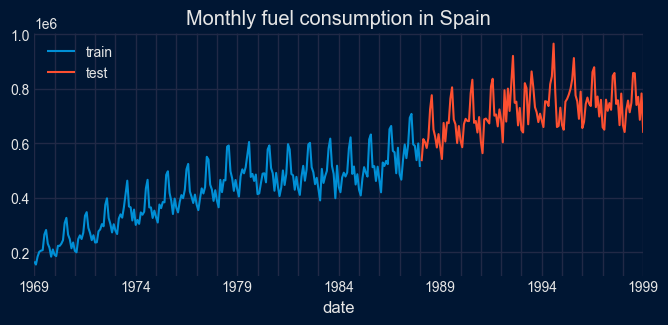

In [5]:
set_dark_theme()
end_train = '1988-01-01 23:59:59'
print(
    f"Train dates : {data.index.min()} --- {data.loc[:end_train].index.max()}  "
    f"(n={len(data.loc[:end_train])})"
)
print(
    f"Test dates  : {data.loc[end_train:].index.min()} --- {data.loc[:].index.max()}  "
    f"(n={len(data.loc[end_train:])})"
)
data_train = data.loc[:end_train]
data_test  = data.loc[end_train:]

# Plot
# ======================================================================================
fig, ax=plt.subplots(figsize=(7, 3))
data_train.plot(ax=ax, label='train')
data_test.plot(ax=ax, label='test')
ax.set_title('Monthly fuel consumption in Spain')
ax.legend()

#### ARIMA Model with Statsmodels SARIMAX Model

In [6]:
warnings.filterwarnings("ignore", category=UserWarning, message='Non-invertible|Non-stationary')
model = SARIMAX(endog = data_train, order = (1, 1, 1), seasonal_order = (1, 1, 1, 12))
model_res = model.fit(disp=0)
warnings.filterwarnings("default")
model_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                            litters   No. Observations:                  229
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -2453.235
Date:                            Thu, 27 Mar 2025   AIC                           4916.469
Time:                                    21:14:25   BIC                           4933.346
Sample:                                01-01-1969   HQIC                          4923.288
                                     - 01-01-1988                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3644      0.120     -3.047      0.002      -0.599      -0.130
ma.L1         -0.2884      0.113     -2.557      0.011      -0.510      -0.067
ar.S.L12       0.0512      0.078      0.658      0.510      -0.101       0.204
ma.S.L12      -0.5582      0.096     -5.797      0.000      -0.747      -0.369
sigma2      4.525e+08   1.56e-10   2.91e+18      0.000    4.53e+08    4.53e+08
===================================================================================
Ljung-Box (L1) (Q):                   3.24   Jarque-Bera (JB):                17.02
Prob(Q):                              0.07   Prob(JB):                         0.00
Heteroskedasticity (H):               0.94   Skew:                            -0.42
Prob(H) (two-sided):                  0.80   Kurtosis:                         4.09
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 4.93e+34. Standard errors may be unstable.
"""

In [7]:
predictions_statsmodels = model_res.get_forecast(steps=len(data_test)).predicted_mean
predictions_statsmodels.name = 'predictions_statsmodels'
display(predictions_statsmodels.head(4))

1988-02-01    495458.423349
1988-03-01    571362.441222
1988-04-01    603685.475822
1988-05-01    578493.310289
Freq: MS, Name: predictions_statsmodels, dtype: float64

#### ARIMA Model with skforecast SARIMAX Model

In [8]:
warnings.filterwarnings("ignore", category=UserWarning, message='Non-invertible|Non-stationary')
model = Sarimax(order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model.fit(y=data_train)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                            litters   No. Observations:                  229
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -2453.235
Date:                            Thu, 27 Mar 2025   AIC                           4916.469
Time:                                    21:14:34   BIC                           4933.346
Sample:                                01-01-1969   HQIC                          4923.288
                                     - 01-01-1988                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3644      0.120     -3.047      0.002      -0.599      -0.130
ma.L1         -0.2884      0.113     -2.557      0.011      -0.510      -0.067
ar.S.L12       0.0512      0.078      0.658      0.510      -0.101       0.204
ma.S.L12      -0.5582      0.096     -5.797      0.000      -0.747      -0.369
sigma2      4.525e+08   1.56e-10   2.91e+18      0.000    4.53e+08    4.53e+08
===================================================================================
Ljung-Box (L1) (Q):                   3.24   Jarque-Bera (JB):                17.02
Prob(Q):                              0.07   Prob(JB):                         0.00
Heteroskedasticity (H):               0.94   Skew:                            -0.42
Prob(H) (two-sided):                  0.80   Kurtosis:                         4.09
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 4.93e+34. Standard errors may be unstable.
"""

In [9]:
predictions_skforecast = model.predict(steps=len(data_test))
predictions_skforecast.columns = ['skforecast']
display(predictions_skforecast.head(4))

,skforecast
1988-02-01,495458.423349
1988-03-01,571362.441222
1988-04-01,603685.475822
1988-05-01,578493.310289


#### ARIMA Model with pmdarima SARIMAX

In [10]:
warnings.filterwarnings("ignore")
model = ARIMA(order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model.fit(y=data_train)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  229
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -2453.170
Date:                            Thu, 27 Mar 2025   AIC                           4918.340
Time:                                    21:14:41   BIC                           4938.592
Sample:                                01-01-1969   HQIC                          4926.522
                                     - 01-01-1988                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    -43.7299    520.562     -0.084      0.933   -1064.013     976.553
ar.L1         -0.3633      0.120     -3.026      0.002      -0.599      -0.128
ma.L1         -0.2899      0.114     -2.544      0.011      -0.513      -0.067
ar.S.L12       0.0522      0.078      0.668      0.504      -0.101       0.205
ma.S.L12      -0.5595      0.096     -5.811      0.000      -0.748      -0.371
sigma2      4.525e+08      0.001    5.7e+11      0.000    4.53e+08    4.53e+08
===================================================================================
Ljung-Box (L1) (Q):                   3.20   Jarque-Bera (JB):                17.08
Prob(Q):                              0.07   Prob(JB):                         0.00
Heteroskedasticity (H):               0.94   Skew:                            -0.42
Prob(H) (two-sided):                  0.80   Kurtosis:                         4.10
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.06e+27. Standard errors may be unstable.
"""

In [11]:
predictions_pdmarima = model.predict(len(data_test))
predictions_pdmarima.name = 'predictions_pdmarima'
display(predictions_pdmarima.head(4))

1988-02-01    495344.458080
1988-03-01    571180.598764
1988-04-01    603414.047394
1988-05-01    578152.152667
Freq: MS, Name: predictions_pdmarima, dtype: float64

#### Comparing Predictions with ARIMA models

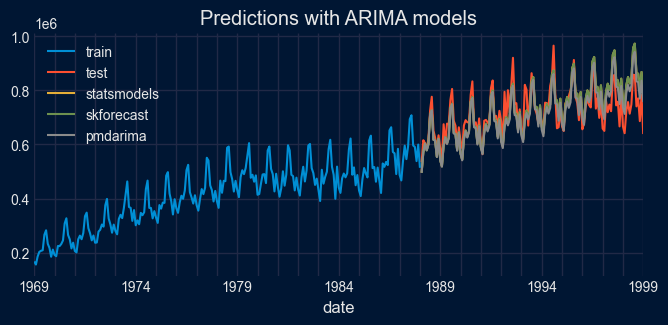

In [12]:
fig, ax = plt.subplots(figsize=(7, 3))
data_train.plot(ax=ax, label='train')
data_test.plot(ax=ax, label='test')
predictions_statsmodels.plot(ax=ax, label='statsmodels')
predictions_skforecast.plot(ax=ax, label='skforecast')
predictions_pdmarima.plot(ax=ax, label='pmdarima')
ax.set_title('Predictions with ARIMA models')
ax.legend();

#### ARIMA Backtesting with ForecasterSarimax & skforecast Sarimax

In [13]:
forecaster = ForecasterSarimax(
                 regressor=Sarimax(order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
             )
forecaster.fit(y=data_train, suppress_warnings=True)

# Prediction
predictions = forecaster.predict(steps=len(data_test))
predictions.head(4)

1988-02-01    495458.423349
1988-03-01    571362.441222
1988-04-01    603685.475822
1988-05-01    578493.310289
Freq: MS, Name: pred, dtype: float64

In [14]:
# Backtest forecaster in terms of MAPE
# ===============================
forecaster = ForecasterSarimax(
                 regressor = Sarimax(
                                order          = (1, 1, 1),
                                seasonal_order =(1, 1, 1, 12),
                                maxiter        = 200
                             )
             )
cv = TimeSeriesFold(
        steps              = 12,
        initial_train_size = len(data_train),
        refit              = True,
        fixed_train_size   = False,
)
metric, predictions = backtesting_sarimax(
                        forecaster            = forecaster,
                        y                     = data,
                        cv                    = cv,
                        metric                = 'mean_absolute_percentage_error',
                        n_jobs                = "auto",
                        suppress_warnings_fit = True,
                        verbose               = True,
                        show_progress         = True
                     )
display(metric)
predictions.head(4)

Information of folds
--------------------
Number of observations used for initial training: 229
Number of observations used for backtesting: 132
    Number of folds: 11
    Number skipped folds: 0 
    Number of steps per fold: 12
    Number of steps to exclude between last observed data (last window) and predictions (gap): 0

Fold: 0
    Training:   1969-01-01 00:00:00 -- 1988-01-01 00:00:00  (n=229)
    Validation: 1988-02-01 00:00:00 -- 1989-01-01 00:00:00  (n=12)
Fold: 1
    Training:   1969-01-01 00:00:00 -- 1989-01-01 00:00:00  (n=241)
    Validation: 1989-02-01 00:00:00 -- 1990-01-01 00:00:00  (n=12)
Fold: 2
    Training:   1969-01-01 00:00:00 -- 1990-01-01 00:00:00  (n=253)
    Validation: 1990-02-01 00:00:00 -- 1991-01-01 00:00:00  (n=12)
Fold: 3
    Training:   1969-01-01 00:00:00 -- 1991-01-01 00:00:00  (n=265)
    Validation: 1991-02-01 00:00:00 -- 1992-01-01 00:00:00  (n=12)
Fold: 4
    Training:   1969-01-01 00:00:00 -- 1992-01-01 00:00:00  (n=277)
    Validation: 1992-02

  0%|          | 0/11 [00:00<?, ?it/s]

,mean_absolute_percentage_error
0,0.036217


,pred
1988-02-01,495458.423349
1988-03-01,571362.441222
1988-04-01,603685.475822
1988-05-01,578493.310289


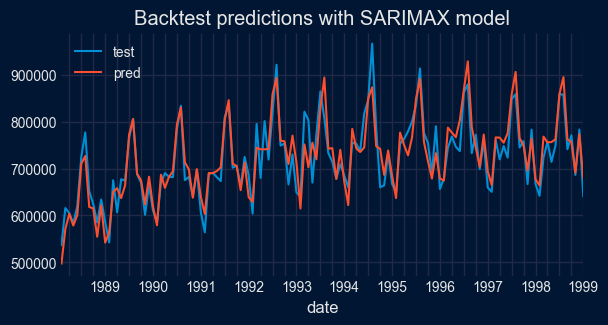

In [15]:
fig, ax = plt.subplots(figsize=(6, 3))
data.loc[end_train:].plot(ax=ax, label='test')
predictions.plot(ax=ax)
ax.set_title('Backtest predictions with SARIMAX model')
ax.legend();

#### Train-Validation-Test Split

In [16]:
end_train = '1984-01-01 23:59:59'
end_val = '1992-01-01 23:59:59'
print(
    f"Train dates      : {data.index.min()} --- {data.loc[:end_train].index.max()}  "
    f"(n={len(data.loc[:end_train])})"
)
print(
    f"Validation dates : {data.loc[end_train:].index.min()} --- {data.loc[:end_val].index.max()}  "
    f"(n={len(data.loc[end_train:end_val])})"
)
print(
    f"Test dates       : {data.loc[end_val:].index.min()} --- {data.index.max()}  "
    f"(n={len(data.loc[end_val:])})"
)

Train dates      : 1969-01-01 00:00:00 --- 1984-01-01 00:00:00  (n=181)
Validation dates : 1984-02-01 00:00:00 --- 1992-01-01 00:00:00  (n=96)
Test dates       : 1992-02-01 00:00:00 --- 1999-01-01 00:00:00  (n=84)


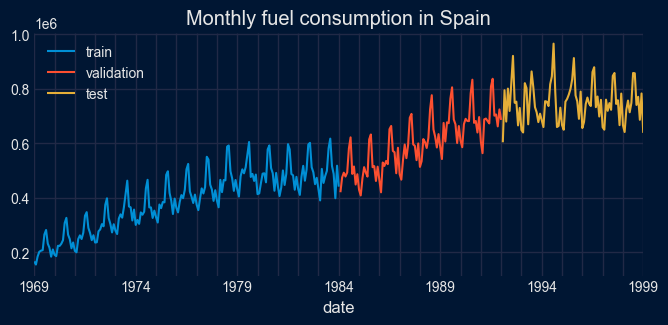

In [17]:
# Plot
# ============
fig, ax = plt.subplots(figsize=(7, 3))
data.loc[:end_train].plot(ax=ax, label='train')
data.loc[end_train:end_val].plot(ax=ax, label='validation')
data.loc[end_val:].plot(ax=ax, label='test')
ax.set_title('Monthly fuel consumption in Spain')
ax.legend();

#### Hyperparameter Optimization with ForecasterSarimax and skforecast Sarimax

In [18]:
forecaster = ForecasterSarimax(
                 regressor = Sarimax(
                                order   = (1, 1, 1), # Placeholder replaced in the grid search
                                maxiter = 500
                             )
             )

param_grid = {
    'order': [(0, 1, 0), (0, 1, 1), (1, 1, 0), (1, 1, 1), (2, 1, 1)],
    'seasonal_order': [(0, 0, 0, 0), (0, 1, 0, 12), (1, 1, 1, 12)],
    'trend': [None, 'n', 'c']
}

cv = TimeSeriesFold(
        steps              = 12,
        initial_train_size = len(data_train),
        refit              = True,
        fixed_train_size   = False,
    )

results_grid = grid_search_sarimax(
                   forecaster            = forecaster,
                   y                     = data.loc[:end_val],
                   cv                    = cv,
                   param_grid            = param_grid,
                   metric                = 'mean_absolute_error',
                   return_best           = False,
                   n_jobs                = 'auto',
                   suppress_warnings_fit = True,
                   verbose               = False,
                   show_progress         = True
               )
results_grid.head(5)

Number of models compared: 45.


params grid:   0%|          | 0/45 [00:00<?, ?it/s]

,params,mean_absolute_error,order,seasonal_order,trend
0,"{'order': (0, 1, 1), 'seasonal_order': (1, 1, ...",17660.029673,"(0, 1, 1)","(1, 1, 1, 12)",n
1,"{'order': (0, 1, 1), 'seasonal_order': (1, 1, ...",17660.029673,"(0, 1, 1)","(1, 1, 1, 12)",None
2,"{'order': (1, 1, 1), 'seasonal_order': (1, 1, ...",17947.891462,"(1, 1, 1)","(1, 1, 1, 12)",None
3,"{'order': (1, 1, 1), 'seasonal_order': (1, 1, ...",17947.891462,"(1, 1, 1)","(1, 1, 1, 12)",n
4,"{'order': (2, 1, 1), 'seasonal_order': (1, 1, ...",17951.493912,"(2, 1, 1)","(1, 1, 1, 12)",n


In [19]:
warnings.filterwarnings("ignore")
model = auto_arima(
            y                 = data.loc[:end_val],
            start_p           = 0,
            start_q           = 0,
            max_p             = 3,
            max_q             = 3,
            seasonal          = True,
            test              = 'adf',
            m                 = 12,   # Seasonal period
            d                 = None, # The algorithm will determine 'd'
            D                 = None, # The algorithm will determine 'D'
            trace             = True,
            error_action      = 'ignore',
            suppress_warnings = True,
            stepwise          = True
        )

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=6131.428, Time=0.20 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=6229.011, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=6059.423, Time=0.12 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=6026.533, Time=0.19 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=6102.080, Time=0.07 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=6028.362, Time=0.48 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=6028.209, Time=0.63 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=6057.553, Time=0.17 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=6025.947, Time=0.95 sec
 ARIMA(0,1,1)(2,1,2)[12]             : AIC=6022.764, Time=1.32 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=6022.643, Time=0.83 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=6022.013, Time=0.60 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=6113.527, Time=0.42 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=6010.743, Time=0.68 sec
 ARIMA(1,1,1)(1,1,0

In [20]:
warnings.filterwarnings("ignore")
buffer = StringIO()
with contextlib.redirect_stdout(buffer):
    auto_arima(
            y                 = data.loc[:end_val],
            start_p           = 0,
            start_q           = 0,
            max_p             = 3,
            max_q             = 3,
            seasonal          = True,
            test              = 'adf',
            m                 = 12,   # Seasonal period
            d                 = None, # The algorithm will determine 'd'
            D                 = None, # The algorithm will determine 'D'
            trace             = True,
            error_action      = 'ignore',
            suppress_warnings = True,
            stepwise          = True
        )
trace_autoarima = buffer.getvalue()
pattern = r"ARIMA\((\d+),(\d+),(\d+)\)\((\d+),(\d+),(\d+)\)\[(\d+)\]\s+(intercept)?\s+:\s+AIC=([\d\.]+), Time=([\d\.]+) sec"
matches = re.findall(pattern, trace_autoarima)
results = pd.DataFrame(
    matches, columns=["p", "d", "q", "P", "D", "Q", "m", "intercept", "AIC", "Time"]
)
results["order"] = results[["p", "d", "q"]].apply(
    lambda x: f"({x.iloc[0]},{x.iloc[1]},{x.iloc[2]})", axis=1
)
results["seasonal_order"] = results[["P", "D", "Q", "m"]].apply(
    lambda x: f"({x.iloc[0]},{x.iloc[1]},{x.iloc[2]},{x.iloc[3]})", axis=1
)
results = results[["order", "seasonal_order", "intercept", "AIC", "Time"]]
results.sort_values(by="AIC").reset_index(drop=True)

,order,seasonal_order,intercept,AIC,Time
0,"(1,1,1)","(2,1,0,12)",,6010.743,0.47
1,"(1,1,1)","(2,1,1,12)",,6011.414,0.77
2,"(1,1,2)","(2,1,0,12)",,6011.658,1.09
3,"(2,1,1)","(2,1,0,12)",,6012.050,2.57
4,"(1,1,1)","(2,1,0,12)",intercept,6012.975,0.62
5,"(0,1,2)","(2,1,0,12)",,6013.683,0.44
6,"(2,1,0)","(2,1,0,12)",,6014.607,0.54
7,"(1,1,1)","(1,1,1,12)",,6016.461,0.36
8,"(0,1,1)","(2,1,0,12)",,6022.013,0.71
9,"(0,1,1)","(2,1,1,12)",,6022.643,0.78


In [21]:
warnings.filterwarnings("ignore")
forecaster = ForecasterSarimax(
                 regressor=Sarimax(order=(1, 1, 1), seasonal_order=(2, 1, 0, 12), maxiter=500),
             )
cv = TimeSeriesFold(
        steps              = 12,
        initial_train_size = len(data.loc[:end_val]),
        refit              = True,
)
metric_m1, predictions_m1 = backtesting_sarimax(
                                forecaster            = forecaster,
                                y                     = data,
                                cv                    = cv,
                                metric                = 'mean_absolute_percentage_error',
                                n_jobs                = "auto",
                                suppress_warnings_fit = True,
                                verbose               = False,
                                show_progress         = True
                            )

# Backtest predictions with the best model according to auto-arima
# ==============================================================================
forecaster = ForecasterSarimax(
                 regressor=Sarimax(order=(1, 1, 1), seasonal_order=(0, 1, 1, 12), maxiter=500),
             )




metric_m2, predictions_m2 = backtesting_sarimax(
                                forecaster            = forecaster,
                                y                     = data,
                                cv                    = cv,
                                metric                = 'mean_absolute_percentage_error',
                                n_jobs                = "auto",
                                suppress_warnings_fit = True,
                                verbose               = False,
                                show_progress         = True
                            )

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

In [22]:
display(metric_m1)

,mean_absolute_percentage_error
0,0.040708


In [23]:
display(metric_m2)

,mean_absolute_percentage_error
0,0.039612


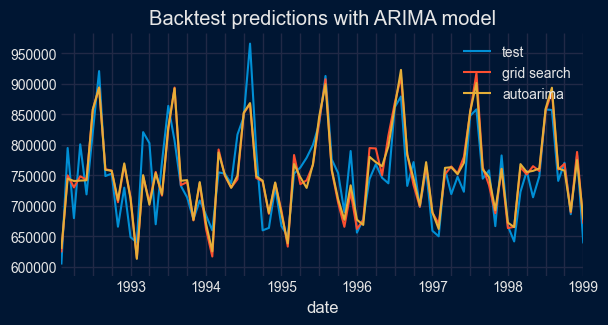

In [24]:
fig, ax = plt.subplots(figsize=(6, 3))
data.loc[end_val:].plot(ax=ax, label='test')
predictions_m1 = predictions_m1.rename(columns={'pred': 'grid search'})
predictions_m2 = predictions_m2.rename(columns={'pred': 'autoarima'})
predictions_m1.plot(ax=ax)
predictions_m2.plot(ax=ax)
ax.set_title('Backtest predictions with ARIMA model')
ax.legend();